<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical_03_PCA_Dimensionality_Reduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 03: Dimensionality Reduction using PCA

## Aim

To apply Principal Component Analysis (PCA) for dimensionality reduction on a dataset.

## Theory

Principal Component Analysis (PCA) is a dimensionality reduction technique used to transform a dataset containing multiple correlated variables into a smaller number of uncorrelated variables called principal components.

The principal components are arranged in descending order according to the amount of variance they explain in the original dataset. The first principal component captures the maximum possible variance, while subsequent components capture the maximum remaining variance.

PCA is useful for:

- Reducing the number of features.
- Removing correlation among features.
- Visualizing high-dimensional datasets.
- Reducing computational complexity.
- Retaining the most important information from the original dataset.

Before applying PCA, the features are standardized so that variables with different scales contribute fairly to the analysis.

## Mathematical Formulation of PCA

Let the standardized dataset be represented by the matrix:

X = [x₁, x₂, ..., xₙ]

The covariance matrix is calculated as:

Cov(X) = (1 / (n − 1)) XᵀX

The principal components are obtained by solving the eigenvalue equation:

Cov(X)v = λv

where:

- λ represents the eigenvalue.
- v represents the corresponding eigenvector.
- Cov(X) represents the covariance matrix.

The eigenvalues determine the amount of variance explained by each principal component.

The explained variance ratio is calculated as:

Explained Variance Ratio = λᵢ / Σλ

The transformed lower-dimensional data is obtained using:

Z = XW

where:

- X = Standardized feature matrix.
- W = Matrix of selected eigenvectors.
- Z = Transformed data containing the principal components.

In this practical, PCA will be used to reduce the Iris dataset from four dimensions to two principal components while retaining most of its information.

In [1]:
# Practical 03: Dimensionality Reduction using PCA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame using the feature names
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst five records:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (150, 4)

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Display dataset information

print("Dataset Information:\n")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Standardize the features before applying PCA

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

print("Standardization completed successfully!")
print("Standardized Dataset Shape:", X_scaled.shape)

print("\nFirst five standardized records:")
display(pd.DataFrame(X_scaled, columns=df.columns).head())

Standardization completed successfully!
Standardized Dataset Shape: (150, 4)

First five standardized records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [5]:
# Apply PCA to reduce the dataset from 4 dimensions to 2 dimensions

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA applied successfully!")

print("Original Number of Features:", X_scaled.shape[1])
print("Reduced Number of Features:", X_pca.shape[1])

print("\nFirst five PCA-transformed records:")
display(
    pd.DataFrame(
        X_pca,
        columns=['PC1', 'PC2']
    ).head()
)

PCA applied successfully!
Original Number of Features: 4
Reduced Number of Features: 2

First five PCA-transformed records:


,PC1,PC2
0,-2.264703,0.480027
1,-2.080961,-0.674134
2,-2.364229,-0.341908
3,-2.299384,-0.597395
4,-2.389842,0.646835


In [6]:
# Calculate explained variance of the principal components

explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")

for i, variance in enumerate(explained_variance, start=1):
    print(f"PC{i}: {variance:.4f}")

print(f"\nTotal Explained Variance: {explained_variance.sum():.4f}")
print(f"Total Explained Variance (%): {explained_variance.sum() * 100:.2f}%")

Explained Variance Ratio:
PC1: 0.7296
PC2: 0.2285

Total Explained Variance: 0.9581
Total Explained Variance (%): 95.81%


In [7]:
# Display PCA component loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns
)

print("PCA Component Loadings:\n")
display(loadings)

PCA Component Loadings:



,PC1,PC2
sepal length (cm),0.521066,0.377418
sepal width (cm),-0.269347,0.923296
petal length (cm),0.580413,0.024492
petal width (cm),0.564857,0.066942


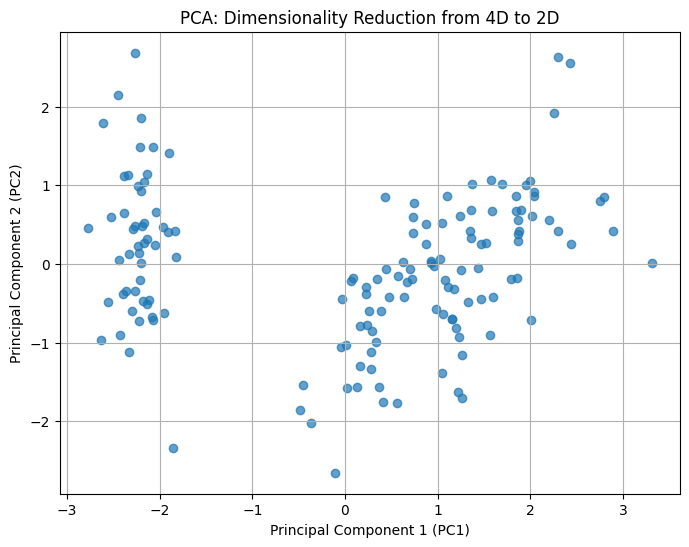

In [8]:
# Visualize the PCA-transformed data

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.7
)

plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA: Dimensionality Reduction from 4D to 2D')
plt.grid(True)
plt.show()

# Result and Conclusion

Principal Component Analysis (PCA) was successfully applied to the Iris dataset to reduce its dimensionality from 4 features to 2 principal components.

The original dataset contained 4 features: sepal length, sepal width, petal length, and petal width. After standardization, PCA transformed these features into two principal components, PC1 and PC2.

PC1 explained **72.96%** of the total variance, while PC2 explained **22.85%**. Together, the two components explained **95.81%** of the total variance in the dataset.

The PCA scatter plot shows that the observations can be represented effectively in a two-dimensional space while retaining most of the information present in the original four-dimensional dataset.

Therefore, PCA successfully reduced the dimensionality of the dataset from 4D to 2D with minimal information loss. This demonstrates that PCA is an effective dimensionality reduction technique for simplifying datasets and making them easier to visualize and analyze.